# QM640 Food Price Affordability AI
## Notebook 08 — HCES-Derived Household Food Affordability Stress Index

**RQ3:** How can forecasted commodity-price changes be translated into a
statistically reliable, interpretable, and stable Household Food Affordability
Stress Index across rural, urban, and expenditure segments?

HCES 2023–24 microdata are used only through disclosure-safe
state–sector–expenditure-decile aggregates. The index is scenario based and
does not claim household-level welfare measurement.


## 1. Setup and verified inputs


In [7]:
from pathlib import Path
import json, os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 190)

try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_ROOT = Path("/content/drive/MyDrive/QM640_Food_Affordability")
else:
    root = Path.cwd().resolve()
    if root.name == "notebooks": root = root.parent
    OUTPUT_ROOT = Path(os.environ.get("QM640_OUTPUT_ROOT", str(root)))

EXTERNAL = OUTPUT_ROOT / "data" / "external_required"
PROCESSED = OUTPUT_ROOT / "data" / "processed"
REPORT_OUTPUT = OUTPUT_ROOT / "reports" / "notebook_outputs"
FIGURES = REPORT_OUTPUT / "figures"
REPORT_OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
SKIP_PLOTS = os.environ.get("QM640_SKIP_PLOTS", "0") == "1"

from scipy.stats import spearmanr
if not SKIP_PLOTS:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")

hces_file = EXTERNAL / "hces_2023_24_segment_aggregates.csv.gz"
if not hces_file.exists():
    raise FileNotFoundError(
        "HCES disclosure-safe aggregate is missing. Upload the file supplied with Notebook 01."
    )
hces = pd.read_csv(hces_file, low_memory=False)
forecast = pd.read_csv(REPORT_OUTPUT / "05_national_24_month_forecast.csv", parse_dates=["date"])
national = pd.read_csv(PROCESSED / "cleaned_national_monthly.csv.gz", parse_dates=["date"], low_memory=False)
forward_risk = pd.read_csv(REPORT_OUTPUT / "06_forward_multihorizon_shock_risk.csv", parse_dates=["target_date"])
nb05 = json.loads((REPORT_OUTPUT / "05_execution_summary.json").read_text(encoding="utf-8"))
nb06 = json.loads((REPORT_OUTPUT / "06_execution_summary.json").read_text(encoding="utf-8"))
print(f"HCES aggregate rows: {len(hces):,}; forecast months: {len(forecast)}")
print(f"HCES sample households represented: {hces['sample_households'].sum():,}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HCES aggregate rows: 719; forecast months: 24
HCES sample households represented: 261,245


## 2. Index formula and 24-month food-cost growth


In [8]:
# Combine observed history and forecast values so each future month has an exact 12-month comparator.
history = national[["date", "food_cpi_2015_100"]].dropna().rename(columns={"food_cpi_2015_100": "cpi"})
future = forecast[["date", "forecast"]].rename(columns={"forecast": "cpi"})
combined = pd.concat([history, future], ignore_index=True).sort_values("date").drop_duplicates("date", keep="last")
lag = combined[["date", "cpi"]].copy()
lag["date"] = lag["date"] + pd.DateOffset(months=12)
lag = lag.rename(columns={"cpi": "cpi_lag12"})
forecast_growth = future.merge(lag, on="date", how="left", validate="one_to_one")
forecast_growth["food_cost_growth_yoy_pct"] = (
    forecast_growth["cpi"] / forecast_growth["cpi_lag12"] - 1
) * 100

for bound, output in [
    ("lower_95_approx", "food_cost_growth_lower_yoy_pct"),
    ("upper_95_approx", "food_cost_growth_upper_yoy_pct"),
]:
    temp = forecast[["date", bound]].merge(lag, on="date", how="left")
    forecast_growth[output] = (temp[bound] / temp["cpi_lag12"] - 1) * 100

SCENARIOS = {
    "Downside (0%)": 0.0,
    "Baseline (4%)": 4.0,
    "Upside (8%)": 8.0,
}

# Neutral = 100. A one-percentage-point excess in food-cost growth adds
# food-share index points. The formula is transparent and dimensionally consistent.
rows = []
for scenario, purchasing_power_growth in SCENARIOS.items():
    cross = hces.assign(_key=1).merge(forecast_growth.assign(_key=1), on="_key").drop(columns="_key")
    cross["purchasing_power_scenario"] = scenario
    cross["purchasing_power_growth_pct"] = purchasing_power_growth
    cross["hfasi"] = 100 + cross["weighted_food_expenditure_share"] * (
        cross["food_cost_growth_yoy_pct"] - purchasing_power_growth
    )
    cross["hfasi_lower"] = 100 + cross["weighted_food_expenditure_share"] * (
        cross["food_cost_growth_lower_yoy_pct"] - purchasing_power_growth
    )
    cross["hfasi_upper"] = 100 + cross["weighted_food_expenditure_share"] * (
        cross["food_cost_growth_upper_yoy_pct"] - purchasing_power_growth
    )
    rows.append(cross)
hfasi = pd.concat(rows, ignore_index=True)
hfasi["affordability_state"] = pd.cut(
    hfasi["hfasi"],
    bins=[-np.inf, 98, 100, 102, np.inf],
    labels=["Relief", "Manageable", "Mild stress", "Elevated stress"],
    right=False,
)
hfasi.to_csv(REPORT_OUTPUT / "08_hfasi_state_sector_decile_24m.csv.gz", index=False, compression="gzip")
forecast_growth.to_csv(REPORT_OUTPUT / "08_forecast_food_cost_growth.csv", index=False)
print(f"HFASI scenario rows: {len(hfasi):,}")


HFASI scenario rows: 51,768


## 3. HCES construct-validity test


In [9]:
# Engel-law construct validity: food-budget share should decline as MPCE rises.
valid = hces[["weighted_mpce_rs", "weighted_food_expenditure_share", "sample_households"]].dropna()
rho, two_sided_p = spearmanr(valid["weighted_mpce_rs"], valid["weighted_food_expenditure_share"])
one_sided_p = two_sided_p / 2 if rho < 0 else 1 - two_sided_p / 2

# Row bootstrap quantifies uncertainty without exposing household records.
rng = np.random.default_rng(640)
bootstrap_rho = []
values = valid[["weighted_mpce_rs", "weighted_food_expenditure_share"]].to_numpy()
for _ in range(2000):
    sample = values[rng.integers(0, len(values), len(values))]
    bootstrap_rho.append(spearmanr(sample[:, 0], sample[:, 1]).statistic)
rho_ci = np.quantile(bootstrap_rho, [0.025, 0.975])

decile_profile = (
    hces.groupby(["sector", "expenditure_decile"], as_index=False)
    .apply(
        lambda g: pd.Series({
            "weighted_food_share": np.average(
                g["weighted_food_expenditure_share"], weights=g["sum_survey_weight"]
            ),
            "weighted_mpce_rs": np.average(
                g["weighted_mpce_rs"], weights=g["sum_survey_weight"]
            ),
            "sample_households": g["sample_households"].sum(),
        }),
        include_groups=False,
    )
)
monotonic_rows = []
for sector, group in decile_profile.groupby("sector"):
    ordered = group.sort_values("expenditure_decile")
    decreases = np.diff(ordered["weighted_food_share"]) <= 0
    monotonic_rows.append({
        "sector": sector,
        "adjacent_decile_comparisons": int(len(decreases)),
        "share_declining_comparisons": int(decreases.sum()),
        "monotonicity_rate": float(decreases.mean()),
    })
monotonicity = pd.DataFrame(monotonic_rows)
validity = pd.DataFrame([{
    "test": "Engel-law construct validity",
    "spearman_rho_mpce_food_share": float(rho),
    "one_sided_p_value_negative": float(one_sided_p),
    "bootstrap_ci_lower": float(rho_ci[0]),
    "bootstrap_ci_upper": float(rho_ci[1]),
    "aggregate_rows": int(len(valid)),
    "interpretation": "negative association supports construct validity; not household-level criterion validity",
}])
validity.to_csv(REPORT_OUTPUT / "08_hfasi_construct_validity.csv", index=False)
decile_profile.to_csv(REPORT_OUTPUT / "08_hces_decile_profile.csv", index=False)
monotonicity.to_csv(REPORT_OUTPUT / "08_hces_decile_monotonicity.csv", index=False)
print(validity.round(5).to_string(index=False))
print(monotonicity.round(4).to_string(index=False))


                        test  spearman_rho_mpce_food_share  one_sided_p_value_negative  bootstrap_ci_lower  bootstrap_ci_upper  aggregate_rows                                                                           interpretation
Engel-law construct validity                      -0.88415                         0.0             -0.9043             -0.8602             719 negative association supports construct validity; not household-level criterion validity
sector  adjacent_decile_comparisons  share_declining_comparisons  monotonicity_rate
 Rural                            9                            9                1.0
 Urban                            9                            9                1.0


## 4. HFASI rank stability and scenario results


In [10]:
baseline = hfasi.loc[hfasi["purchasing_power_scenario"].eq("Baseline (4%)")].copy()
baseline["segment_id"] = (
    baseline["state"].astype(str) + "|" + baseline["sector"].astype(str)
    + "|D" + baseline["expenditure_decile"].astype(str)
)
rank_matrix = baseline.pivot(index="segment_id", columns="date", values="hfasi").rank(axis=0, ascending=False)
rank_correlations = rank_matrix.corr(method="spearman")
upper = rank_correlations.where(np.triu(np.ones(rank_correlations.shape), k=1).astype(bool)).stack()
mean_rank_stability = float(upper.mean())
minimum_rank_stability = float(upper.min())

scenario_summary = (
    hfasi.groupby(["purchasing_power_scenario", "sector", "expenditure_decile"], as_index=False)
    .agg(
        mean_hfasi=("hfasi", "mean"),
        maximum_hfasi=("hfasi", "max"),
        minimum_hfasi=("hfasi", "min"),
        months_elevated=("hfasi", lambda x: int(x.ge(102).sum())),
        segments=("state", "nunique"),
    )
)
scenario_summary.to_csv(REPORT_OUTPUT / "08_hfasi_scenario_summary.csv", index=False)
rank_correlations.to_csv(REPORT_OUTPUT / "08_hfasi_rank_correlations.csv")

construct_valid = bool((rho < 0) and (one_sided_p < 0.05) and (rho_ci[1] < 0))
stable_enough = bool(mean_rank_stability >= 0.70)
h0_3_decision = (
    "provisional_reject_H0_3_construct_valid_and_stable"
    if construct_valid and stable_enough
    else "fail_to_reject_H0_3"
)
print(scenario_summary.round(3).head(30).to_string(index=False))
print(f"\nMean pairwise monthly rank stability: {mean_rank_stability:.3f}")
print(f"RQ3 provisional decision: {h0_3_decision}")


purchasing_power_scenario sector  expenditure_decile  mean_hfasi  maximum_hfasi  minimum_hfasi  months_elevated  segments
            Baseline (4%)  Rural                   1      98.822         99.758         96.360                0        36
            Baseline (4%)  Rural                   2      98.918         99.701         96.417                0        35
            Baseline (4%)  Rural                   3      98.999         99.720         96.435                0        36
            Baseline (4%)  Rural                   4      99.070         99.745         96.651                0        36
            Baseline (4%)  Rural                   5      99.154         99.759         96.836                0        36
            Baseline (4%)  Rural                   6      99.202         99.763         96.856                0        36
            Baseline (4%)  Rural                   7      99.269         99.787         97.051                0        36
            Baseline (4%

## 5. Figures for the interim report


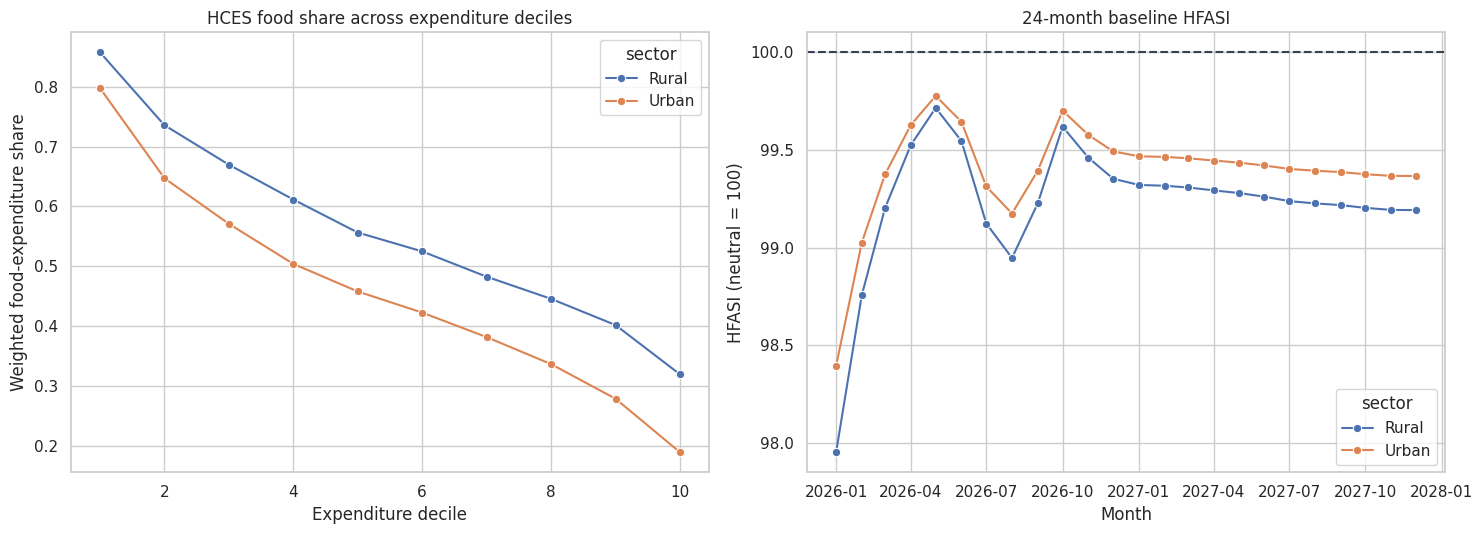

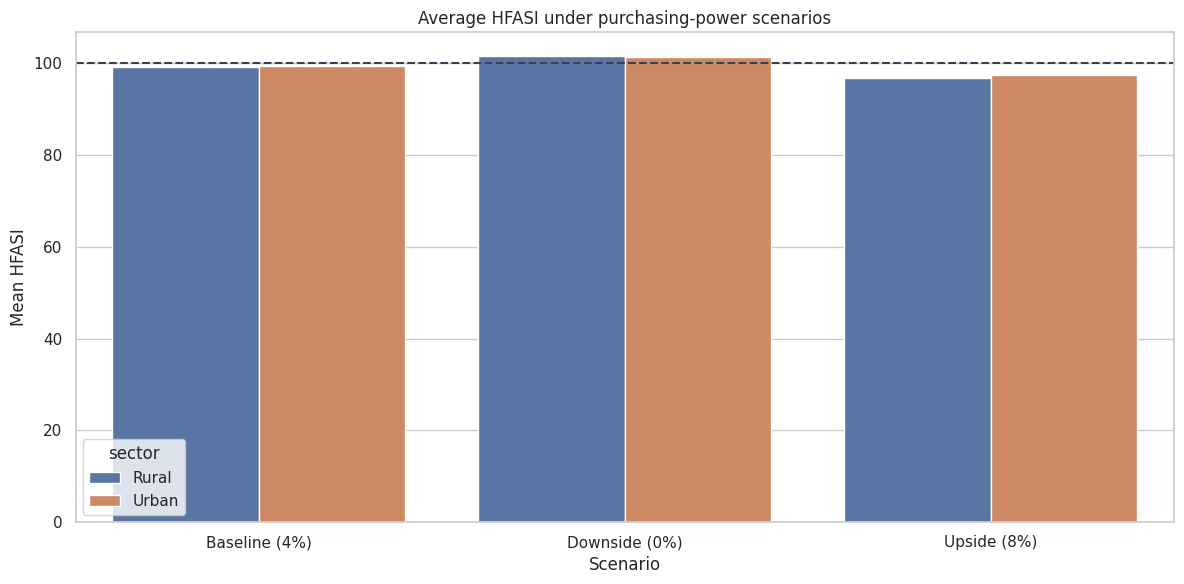

In [11]:
if not SKIP_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    sns.lineplot(
        data=decile_profile, x="expenditure_decile", y="weighted_food_share",
        hue="sector", marker="o", ax=axes[0]
    )
    axes[0].set(title="HCES food share across expenditure deciles",
                xlabel="Expenditure decile", ylabel="Weighted food-expenditure share")
    sector_month = (
        baseline.groupby(["date", "sector"], as_index=False)
        .apply(lambda g: pd.Series({"hfasi": np.average(g["hfasi"], weights=g["sum_survey_weight"])}),
               include_groups=False)
    )
    sns.lineplot(data=sector_month, x="date", y="hfasi", hue="sector", marker="o", ax=axes[1])
    axes[1].axhline(100, linestyle="--", color="#374151")
    axes[1].set(title="24-month baseline HFASI", xlabel="Month", ylabel="HFASI (neutral = 100)")
    fig.tight_layout()
    fig.savefig(FIGURES / "08_hces_validity_and_hfasi.png", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))
    plot = scenario_summary.groupby(["purchasing_power_scenario", "sector"], as_index=False)["mean_hfasi"].mean()
    sns.barplot(data=plot, x="purchasing_power_scenario", y="mean_hfasi", hue="sector", ax=ax)
    ax.axhline(100, linestyle="--", color="#374151")
    ax.set(title="Average HFASI under purchasing-power scenarios", xlabel="Scenario", ylabel="Mean HFASI")
    fig.tight_layout()
    fig.savefig(FIGURES / "08_hfasi_scenarios.png", bbox_inches="tight")
    plt.show()


## 6. Execution summary


In [12]:
highest = hfasi.loc[hfasi["hfasi"].idxmax()]
summary = {
    "notebook": "08_affordability_index_synopsis_aligned",
    "status": "completed",
    "research_question_preserved": True,
    "index_name": "Household Food Affordability Stress Index (HFASI)",
    "formula": "100 + HCES food share × (forecast food-cost growth − purchasing-power growth)",
    "hces_survey": "2023-24",
    "hces_aggregate_rows": int(len(hces)),
    "hces_sample_households_represented": int(hces["sample_households"].sum()),
    "states_uts": int(hces["state"].nunique()),
    "sectors": sorted(hces["sector"].dropna().unique().tolist()),
    "expenditure_deciles": sorted(hces["expenditure_decile"].astype(int).unique().tolist()),
    "forecast_months": int(forecast_growth["date"].nunique()),
    "construct_validity_spearman_rho": float(rho),
    "construct_validity_one_sided_p": float(one_sided_p),
    "construct_validity_bootstrap_95_ci": [float(rho_ci[0]), float(rho_ci[1])],
    "mean_monthly_rank_stability": mean_rank_stability,
    "minimum_monthly_rank_stability": minimum_rank_stability,
    "rq3_hypothesis_decision": h0_3_decision,
    "highest_hfasi": float(highest["hfasi"]),
    "highest_hfasi_scenario": str(highest["purchasing_power_scenario"]),
    "highest_hfasi_state": str(highest["state"]),
    "highest_hfasi_sector": str(highest["sector"]),
    "highest_hfasi_decile": int(highest["expenditure_decile"]),
    "highest_hfasi_month": str(pd.Timestamp(highest["date"]).date()),
    "interpretation": (
        "Construct-valid, scenario-based segment index; not a household-level "
        "welfare threshold or causal effect."
    ),
    "output_root": str(OUTPUT_ROOT),
}
SUMMARY_FILE = REPORT_OUTPUT / "08_execution_summary.json"
SUMMARY_FILE.write_text(json.dumps(summary, indent=2), encoding="utf-8")
expected = [
    REPORT_OUTPUT / "08_hfasi_state_sector_decile_24m.csv.gz",
    REPORT_OUTPUT / "08_forecast_food_cost_growth.csv",
    REPORT_OUTPUT / "08_hfasi_construct_validity.csv",
    REPORT_OUTPUT / "08_hces_decile_profile.csv",
    REPORT_OUTPUT / "08_hces_decile_monotonicity.csv",
    REPORT_OUTPUT / "08_hfasi_scenario_summary.csv",
    REPORT_OUTPUT / "08_hfasi_rank_correlations.csv",
    SUMMARY_FILE,
]
if not SKIP_PLOTS:
    expected += [FIGURES / "08_hces_validity_and_hfasi.png", FIGURES / "08_hfasi_scenarios.png"]
missing = [str(p) for p in expected if not p.exists()]
if missing: raise FileNotFoundError("\n".join(missing))
print("=" * 76)
print("NOTEBOOK 08 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT")
print("=" * 76)
print(json.dumps(summary, indent=2))
print(f"\nVerified artifacts: {len(expected)}")


NOTEBOOK 08 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT
{
  "notebook": "08_affordability_index_synopsis_aligned",
  "status": "completed",
  "research_question_preserved": true,
  "index_name": "Household Food Affordability Stress Index (HFASI)",
  "formula": "100 + HCES food share \u00d7 (forecast food-cost growth \u2212 purchasing-power growth)",
  "hces_survey": "2023-24",
  "hces_aggregate_rows": 719,
  "hces_sample_households_represented": 261245,
  "states_uts": 36,
  "sectors": [
    "Rural",
    "Urban"
  ],
  "expenditure_deciles": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ],
  "forecast_months": 24,
  "construct_validity_spearman_rho": -0.8841472075373542,
  "construct_validity_one_sided_p": 1.8427032319808458e-239,
  "construct_validity_bootstrap_95_ci": [
    -0.9043015581213225,
    -0.8602018599779312
  ],
  "mean_monthly_rank_stability": 1.0,
  "minimum_monthly_rank_stability": 1.0,
  "rq3_hypothesis_decision": "provisional_rejec

## Notebook 08 conclusion

HFASI is transparent and segment-sensitive. The HCES Engel-law test supplies
construct-validity evidence and the forecast exercise tests rank stability.
Because only disclosure-safe aggregates are used, the result is provisional
segment-level evidence—not a household-specific welfare classification.
